In [1]:
import json
import os
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np

SOURCE_DATA_DIR = Path(os.environ["SOURCE_DATA_DIR"])
OUTPUT_DATA_DIR = Path(os.environ["OUTPUT_DATA_DIR"])

BLOCK_SIZE = 50  # must match the value used in detect_changepoints

In [2]:
import sys
sys.path.insert(0, str(Path("__file__").resolve().parent.parent))
from analysis.changepoints import load_all_attempts

Saved → /home/cleode5a7/Desktop/werk/neuromod/Mario_behaviour/output_data/changepoints/figure_changepoints.png


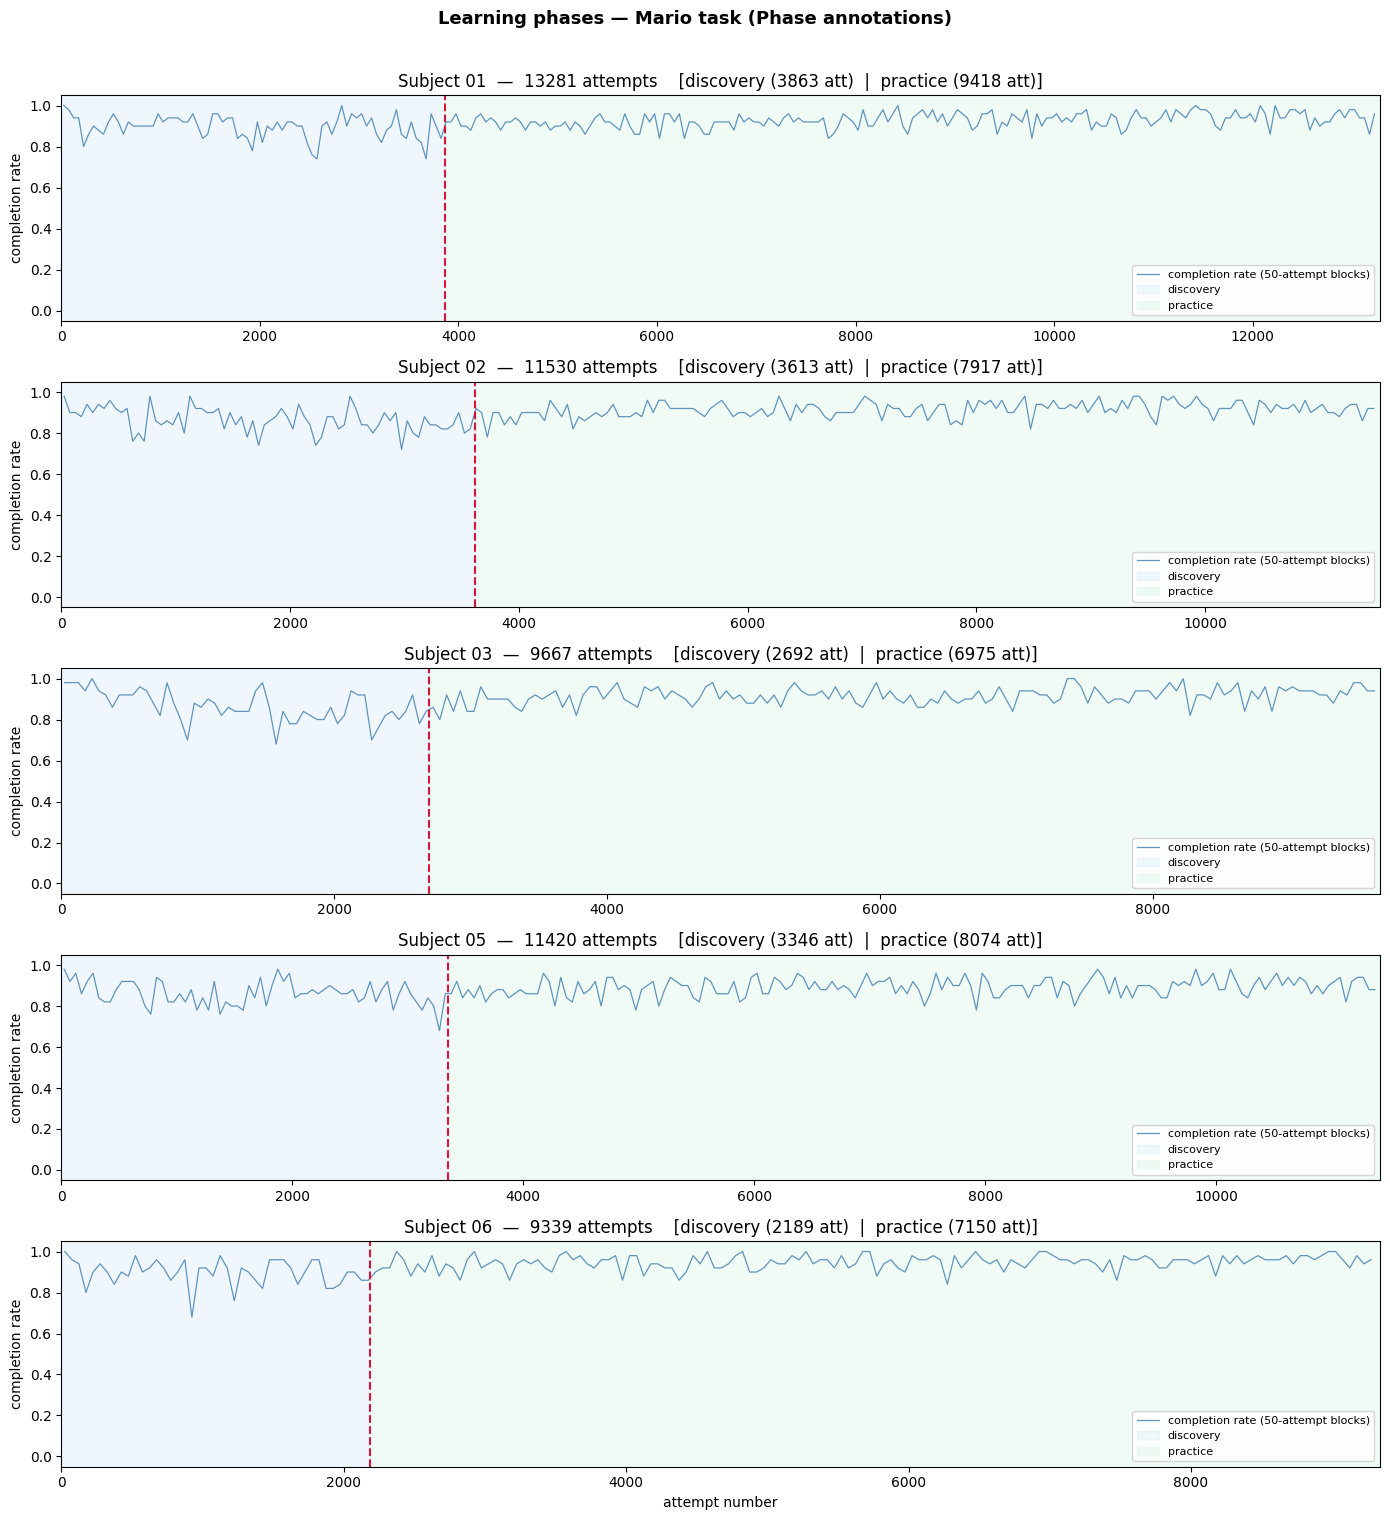

In [3]:
cp_files = sorted((OUTPUT_DATA_DIR / "changepoints").glob("*_changepoints.json"))

fig, axes = plt.subplots(len(cp_files), 1, figsize=(14, 3 * len(cp_files)), sharex=False)
if len(cp_files) == 1:
    axes = [axes]

PHASE_COLORS = {
    "discovery": "#d6eaf8",
    "practice":  "#d5f5e3",
    "other":     "#fef9e7",
}

for ax, cp_file in zip(axes, cp_files):
    result = json.loads(cp_file.read_text())
    subject = result["subject"]
    changepoints = result["changepoints"]
    phases = result.get("phases", [])

    # reconstruct the completion series and block means for display
    records = load_all_attempts(subject, SOURCE_DATA_DIR)
    completions = np.array([1 if r["Outcome"] == "completed" else 0 for r in records], dtype=float)

    n_blocks = len(completions) // BLOCK_SIZE
    blocks = completions[:n_blocks * BLOCK_SIZE].reshape(n_blocks, BLOCK_SIZE).mean(axis=1)
    attempt_axis = np.arange(n_blocks) * BLOCK_SIZE + BLOCK_SIZE // 2

    ax.plot(attempt_axis, blocks, color="steelblue", linewidth=0.9, alpha=0.85,
            label="completion rate (50-attempt blocks)")

    # shade each annotated phase
    for phase_info in phases:
        label = phase_info["phase"]
        color = PHASE_COLORS.get(label, PHASE_COLORS["other"])
        ax.axvspan(phase_info["start"], phase_info["end"], alpha=0.35, color=color, zorder=0,
                   label=label)

    # vertical lines at phase transitions
    for cp in changepoints:
        ax.axvline(cp, color="crimson", linewidth=1.5, linestyle="--")

    ax.set_xlim(0, len(completions))
    ax.set_ylim(-0.05, 1.05)
    ax.set_ylabel("completion rate")

    phase_summary = "  |  ".join(f"{p['phase']} ({p['end']-p['start']} att)" for p in phases)
    ax.set_title(f"Subject {subject}  —  {len(completions)} attempts    [{phase_summary}]")

    # de-duplicate legend
    handles, labels = ax.get_legend_handles_labels()
    seen = {}
    for h, l in zip(handles, labels):
        seen.setdefault(l, h)
    ax.legend(seen.values(), seen.keys(), loc="lower right", fontsize=8)

axes[-1].set_xlabel("attempt number")
fig.suptitle("Learning phases — Mario task (Phase annotations)", fontsize=13, fontweight="bold", y=1.01)
fig.tight_layout()

out_path = OUTPUT_DATA_DIR / "changepoints" / "figure_changepoints.png"
fig.savefig(out_path, dpi=150, bbox_inches="tight")
print(f"Saved → {out_path}")
plt.show()